# Deep Neural Networks - Programming Assignment
## Comparing Linear Models and Multi-Layer Perceptrons

**Student Name:** ___________________  
**Student ID:** ___________________  
**Date:** ___________________

---

## ⚠️ IMPORTANT INSTRUCTIONS

1. **Complete ALL sections** marked with `TODO`
2. **DO NOT modify** the `get_assignment_results()` function structure
3. **Fill in all values accurately** - these will be auto-verified
4. **After submission**, you'll receive a verification quiz based on YOUR results
5. **Run all cells** before submitting (Kernel → Restart & Run All)

---

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)
print('✓ Libraries imported successfully')

✓ Libraries imported successfully


## Section 1: Dataset Selection and Loading

**Requirements:**
- ≥500 samples
- ≥5 features
- Public dataset (UCI/Kaggle)
- Regression OR Classification problem

In [2]:
# TODO: Load your dataset
# Example: data = pd.read_csv('your_dataset.csv')
data = pd.read_csv('mushrooms.csv')
# Dataset information (TODO: Fill these)
dataset_name = "Mushrooms Classification"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "Kaggle"  # e.g., "UCI ML Repository"
n_samples = 8124      # Total number of rows
n_features = 22     # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
TODO: Describe what you're predicting and why it matters.
Example: "Predicting tumor malignancy from diagnostic measurements.
This is critical for early cancer detection in medical diagnosis."
"""

# Primary evaluation metric (TODO: Fill this)
primary_metric = "recall"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """
TODO: Explain why you chose this metric.
Example: "I chose recall because in medical diagnosis,
false negatives (missing cancer) are more costly than false positives."
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Mushrooms Classification
Source: Kaggle
Samples: 8124, Features: 22
Problem Type: binary_classification
Primary Metric: recall


In [3]:
# TODO: Load your dataset
# DataSet Source:
# https://www.kaggle.com/datasets/uciml/mushroom-classification

# https://archive.ics.uci.edu/dataset/73/mushroom

data = pd.read_csv('mushrooms.csv')

# Dataset information (TODO: Fill these)
dataset_name = "Mushrooms Classification"  # e.g., "Breast Cancer Wisconsin"
dataset_source = "Kaggle"  # e.g., "UCI ML Repository"
n_samples = 8124      # Total number of rows
n_features = 22     # Number of features (excluding target)
problem_type = "binary_classification"  # "regression" or "binary_classification" or "multiclass_classification"

# Problem statement (TODO: Write 2-3 sentences)
problem_statement = """
Develop a machine learning model to classify mushrooms as edible or poisonous using their categorical attributes.
Accurate classification is essential for safety, as incorrectly identifying a toxic mushroom as edible can lead to serious or potentially fatal health outcomes.
"""


# Primary evaluation metric (TODO: Fill this)
primary_metric = "recall"  # e.g., "recall", "accuracy", "rmse", "r2"

# Metric justification (TODO: Write 2-3 sentences)
metric_justification = """
Recall is chosen because missing a poisonous mushroom (a false negative) can have
serious or fatal consequences. Prioritizing recall helps ensure the model correctly
identifies as many poisonous mushrooms as possible, even if it results in more false positives.
"""

print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Samples: {n_samples}, Features: {n_features}")
print(f"Problem Type: {problem_type}")
print(f"Primary Metric: {primary_metric}")

Dataset: Mushrooms Classification
Source: Kaggle
Samples: 8124, Features: 22
Problem Type: binary_classification
Primary Metric: recall


## Section 2: Data Preprocessing

Preprocess your data:
1. Handle missing values
2. Encode categorical variables
3. Split into train/test sets
4. Scale features

In [4]:
# TODO: Preprocess your data
# 1. Separate features (X) and target (y)
# 2. Handle missing values if any
# 3. Encode categorical variables

# Example:
# X = data.drop('target', axis=1)
# y = data['target']

# 1. separating features (X) and target (y)
y = data['class'].map({'p': 1, 'e': 0})
X = data.drop('class', axis=1)
# print(f"Features (X) shape: {X.shape}")
# print(f"Target (y) shape: {y.shape}")

# 2. handling missing values
missing_counts = (X == '?').sum() # In this dataset, missing values are represented by '?'
# print("Columns containing '?' as missing vales:")
# print(missing_counts[missing_counts > 0])

# The 'stalk-root' column has missing values, as observed during the data analysis step.
# I am replacing these missing entries with the mode of the column to maintain consistency in the dataset.

X.replace('?', np.nan, inplace=True)
mode = X['stalk-root'].mode()[0]
X['stalk-root'].fillna(mode, inplace=True)
# print(f"\nReplaced missing values in 'stalk-root' with the mode: '{mode}'")
# print("Total missing values after imputation:")
# print(X.isnull().sum().sum()) # --> this will be now 0

# 3. Encoding categorical variables

# Since machine learning models require numerical inputs, I am applying One-Hot Encoding
# to convert each categorical value into separate binary (0/1) columns.
# The pd.get_dummies() function provides an easy way to perform this transformation.

# I am using drop_first=True to remove redundant dummy variables.
# For example, if a feature has categories like 'red' and 'blue', keeping only one dummy column
# (e.g., 'is_blue') is enough, because a value of 0 would automatically indicate 'red'.

X_encoded = pd.get_dummies(X, drop_first=True)
# print(f"Number of features before encoding: {X.shape[1]}")
# print(f"Number of features after encoding: {X_encoded.shape[1]}")
# print("Shape of the final processed feature set (X_encoded):", X_encoded.shape)
# print(X_encoded.head())

# TODO: Train-test split
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)
# print(f"Training features shape (X_train): {X_train.shape}")
# print(f"Training target shape (y_train): {y_train.shape}")
# print(f"Testing features shape (X_test): {X_test.shape}")
# print(f"Testing target shape (y_test): {y_test.shape}")

# print("\nProportion of each class in the training set:")
# print(y_train.value_counts(normalize=True))

# print("\nProportion of each class in the test set:")
# print(y_test.value_counts(normalize=True))


# TODO: Feature scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fill these after preprocessing
train_samples = X_train.shape[0]       # Number of training samples
test_samples = X_test.shape[0]        # Number of test samples
total_samples = train_samples + test_samples
train_test_ratio = train_samples /  total_samples # e.g., 0.8 for 80-20 split

print(f"Train samples: {train_samples}")
print(f"Test samples: {test_samples}")
print(f"Split ratio: {train_test_ratio:.1%}")

Train samples: 6499
Test samples: 1625
Split ratio: 80.0%


## Section 3: Baseline Model Implementation

Implement from scratch (NO sklearn models!):
- Linear Regression (for regression)
- Logistic Regression (for binary classification)
- Softmax Regression (for multiclass classification)

**Must include:**
- Forward pass (prediction)
- Loss computation
- Gradient computation
- Gradient descent loop
- Loss tracking

In [5]:
class BaselineModel:
    """
    Baseline linear model with gradient descent
    Implement: Linear/Logistic/Softmax Regression
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        """
        Internal helper function that computes the Sigmoid activation: 1 / (1 + e^-z).
        I use np.clip to prevent numerical overflow or underflow when applying the exponential.
        """
        z_clipped = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z_clipped))

    def _compute_cost(self, y, A, n_samples):
        """
        Internal helper function that calculates the Binary Cross-Entropy (Log Loss) cost.
        """
        # Clipping A prevents issues such as log(0), which is - infinity.
        A_clipped = np.clip(A, 1e-10, 1 - 1e-10)
        cost = -(1 / n_samples) * np.sum(y * np.log(A_clipped) + (1 - y) * np.log(1 - A_clipped))
        return cost

    def fit(self, X, y):
        """
        TODO: Implement gradient descent training

        Steps:
        1. Initialize weights and bias
        2. For each iteration:
           a. Compute predictions (forward pass)
           b. Compute loss
           c. Compute gradients
           d. Update weights and bias
           e. Store loss in self.loss_history

        Must populate self.loss_history with loss at each iteration!
        """
        n_samples, n_features = X.shape
        # to make sure y is a 1D numpy array
        y = y.values if hasattr(y, 'values') else y
        # TODO: Initialize parameters
        self.weights = np.zeros(n_features)
        self.bias = 0

        # TODO: Implement gradient descent loop
        for i in range(self.n_iterations):
            # 1. Forward pass: y_pred = ...
            # linear part z = weights*X + bias
            z = np.dot(X, self.weights) + self.bias
            # activation part, i am using _sigmoid
            A = self._sigmoid(z)

            # 2. Compute loss
            cost = self._compute_cost(y, A, n_samples)

            # 3. Compute gradients: dw = ..., db = ...
            dw = (1 / n_samples) * np.dot(X.T, (A - y))
            # Derivative of cost w.r.t bias (db)
            db = (1 / n_samples) * np.sum(A - y)

            # 4. Update: self.weights -= self.lr * dw
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            # 5. self.loss_history.append(loss)
            self.loss_history.append(cost)

        return self
    def predict_proba(self, X):
        """
        Returns the predicted probability for each sample belonging to the positive class.
        """
        if self.weights is None or self.bias is None:
            raise Exception("Model has not been trained yet. Please run .fit() before calling this method.")

        z = np.dot(X, self.weights) + self.bias
        return self._sigmoid(z)

    def predict(self, X, threshold=0.5):
      # by default i am taking threshold as 0.5
        """
        TODO: Implement prediction

        For regression: return linear_output
        For classification: return class probabilities or labels
        """
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

print("✓ Baseline model class defined")

✓ Baseline model class defined


In [6]:
# Train baseline model
print("Training baseline model...")
baseline_start_time = time.time()

# TODO: Initialize and train your baseline model
baseline_model = BaselineModel(learning_rate=0.01, n_iterations=1000)
baseline_model.fit(X_train_scaled, y_train)

# TODO: Make predictions
baseline_predictions = baseline_model.predict(X_test_scaled)

baseline_training_time = time.time() - baseline_start_time
print(f"✓ Baseline training completed in {baseline_training_time:.2f}s")
print(f"✓ Loss decreased from {baseline_model.loss_history[0]:.4f} to {baseline_model.loss_history[-1]:.4f}")

Training baseline model...
✓ Baseline training completed in 4.58s
✓ Loss decreased from 0.6931 to 0.0422


## Section 4: Multi-Layer Perceptron Implementation

Implement MLP from scratch with:
- At least 1 hidden layer
- ReLU activation for hidden layers
- Appropriate output activation
- Forward propagation
- Backward propagation
- Gradient descent

In [7]:
class MLP:
    """
    Multi-Layer Perceptron implemented from scratch
    Note: (Using ReLU for hidden layers and Sigmoid for output)
    """
    def __init__(self, architecture, learning_rate=0.01, n_iterations=1000):
        """
        architecture: list [input_size, hidden1, hidden2, ..., output_size]
        Example: [30, 16, 8, 1] means:
            - 30 input features
            - Hidden layer 1: 16 neurons
            - Hidden layer 2: 8 neurons
            - Output layer: 1 neuron
        """
        self.architecture = architecture
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.parameters = {}
        self.loss_history = []
        self.cache = {}

    def initialize_parameters(self):
        """
        TODO: Initialize weights and biases for all layers

        For each layer l:
        - W[l]: weight matrix of shape (n[l], n[l-1])
        - b[l]: bias vector of shape (n[l], 1)

        Store in self.parameters dictionary
        """
        np.random.seed(42)

        for l in range(1, len(self.architecture)):
            # TODO: Initialize weights and biases
            # self.parameters[f'W{l}'] = ...
            # self.parameters[f'b{l}'] = ...
            n_l = self.architecture[l]
            n_l_prev = self.architecture[l-1]
            # I am using He initialization for the weight matrices since the hidden layers use ReLU.
            # This method helps maintain stable gradients during training.
            self.parameters[f'W{l}'] = np.random.randn(n_l, n_l_prev) * np.sqrt(2 / n_l_prev)
            # print(f"Initialized W{l} with shape: {self.parameters[f'W{l}'].shape}")

            # Bias values are initialized to zero for each neuron in the layer.
            self.parameters[f'b{l}'] = np.zeros((n_l, 1))
            # print(f"Initialized b{l} with shape: {self.parameters[f'b{l}'].shape}")

    def relu(self, Z):
        """ReLU activation function"""
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
      # if not working, change this implementaion
        """ReLU derivative"""
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        """Sigmoid activation (for binary classification output)"""
        return 1 / (1 + np.exp(-np.clip(Z, -500, 500)))

    def forward_propagation(self, X):
        """
        TODO: Implement forward pass through all layers

        For each layer:
        1. Z[l] = W[l] @ A[l-1] + b[l]
        2. A[l] = activation(Z[l])

        Store Z and A in self.cache for backpropagation
        Return final activation A[L]
        """
        A = X.T # taking A as X transpose, for sake of simplicity
        self.cache['A0'] = A
        total_layer = len(self.architecture) - 1 # Number of layers

        # TODO: Implement forward pass
        # for l in range(1, len(self.architecture)):
        #     ...

        for l in range(1, total_layer):
            W = self.parameters[f'W{l}']
            b = self.parameters[f'b{l}']

            Z = W @ A + b
            A = self.relu(Z) # <-- using ReLU for hidden
            self.cache[f'Z{l}'] = Z
            self.cache[f'A{l}'] = A

        # explicitly handling output layer because we are using sigmoid at output layer
        W = self.parameters[f'W{total_layer}']
        b = self.parameters[f'b{total_layer}']
        Z = W @ A + b
        A = self.sigmoid(Z) # <-- Use Sigmoid for output
        self.cache[f'Z{total_layer}'] = Z
        self.cache[f'A{total_layer}'] = A
        return A

    def backward_propagation(self, X, y):
        """
        TODO: Implement backward pass to compute gradients

        Starting from output layer, compute:
        1. dZ[l] for each layer
        2. dW[l] = dZ[l] @ A[l-1].T / m
        3. db[l] = sum(dZ[l]) / m

        Return dictionary of gradients
        """
        m = X.shape[0]
        grads = {}
        total_layer = len(self.architecture) - 1
        Y_true_T = y.T # takning transpose for sake of simplicity

        # TODO: Implement backward pass
        # Start with output layer gradient
        A_L = self.cache[f'A{total_layer}']
        A_prev = self.cache[f'A{total_layer-1}'] # Activation from last hidden layer
        dZ_L = A_L - Y_true_T
        grads[f'dW{total_layer}'] = (1/m) * (dZ_L @ A_prev.T)
        grads[f'db{total_layer}'] = (1/m) * np.sum(dZ_L, axis=1, keepdims=True)
        # Gradient to propagate backward
        dA_prev = self.parameters[f'W{total_layer}'].T @ dZ_L

        # Then propagate backwards through hidden layers
        for l in range(total_layer-1, 0, -1):
            A_prev = self.cache[f'A{l-1}']
            Z_l = self.cache[f'Z{l}'] # Need Z for ReLU derivative
            # Gradient of loss w.r.t Z_l
            # The derivative of ReLU is 1 if Z > 0, else 0
            relu_prime = self.relu_derivative(Z_l)
            dZ_l = dA_prev * relu_prime # (n[l], n_samples)

            grads[f'dW{l}'] = (1/m) * (dZ_l @ A_prev.T)
            grads[f'db{l}'] = (1/m) * np.sum(dZ_l, axis=1, keepdims=True)

            # Gradient to propagate to the next layer (l-1)
            dA_prev = self.parameters[f'W{l}'].T @ dZ_l

        return grads

    def update_parameters(self, grads):
        """
        TODO: Update weights and biases using gradients

        For each layer:
        W[l] = W[l] - learning_rate * dW[l]
        b[l] = b[l] - learning_rate * db[l]
        """
        # TODO: Implement parameter updates
        total_layer = len(self.architecture) - 1
        for l in range(1, total_layer + 1):
            self.parameters[f'W{l}'] -= self.lr * grads[f'dW{l}']
            self.parameters[f'b{l}'] -= self.lr * grads[f'db{l}']

    def compute_loss(self, y_pred, y_true):
        """
        TODO: Compute loss

        For regression: MSE
        For classification: Cross-entropy
        """
        # standard implementaion of Cross-entropy
        m = y_true.shape[1]
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        cost = -(1/m) * np.sum(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return np.squeeze(cost)

    def fit(self, X, y):
        """
        TODO: Implement training loop

        For each iteration:
        1. Forward propagation
        2. Compute loss
        3. Backward propagation
        4. Update parameters
        5. Store loss

        Must populate self.loss_history!
        """
        if hasattr(X, 'values'):
            X = X.values
        if hasattr(y, 'values'):
            y = y.values
        if y.ndim == 1:
          # reshaping to ensures the dimensions are correct before training
            y = y.reshape(-1, 1)

        self.initialize_parameters()
        self.loss_history = []
        for i in range(self.n_iterations):
            # TODO: Training loop
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y_pred, y.T)
            self.loss_history.append(loss)
            grads = self.backward_propagation(X, y)
            self.update_parameters(grads)
            # print(f"Iteration {i+1}/{self.n_iterations}, Loss: {loss:.6f}")
        return self

    def predict(self, X):
        """
        TODO: Implement prediction

        Use forward_propagation and apply appropriate thresholding
        """
        y_prob = self.forward_propagation(X)
        y_prob_T = y_prob.T
        y_pred = (y_prob_T > 0.5).astype(int)
        return y_pred

print("✓ MLP class defined")

✓ MLP class defined


In [8]:
# Train MLP
print("Training MLP...")
mlp_start_time = time.time()

# TODO: Define your architecture and train MLP
mlp_architecture = [X_train_scaled.shape[1], 16, 8, 1]  # Example: [n_features, 16, 8, 1]
mlp_model = MLP(architecture=mlp_architecture, learning_rate=0.01, n_iterations=1000)
mlp_model.fit(X_train_scaled, y_train)


# TODO: Make predictions
mlp_predictions = mlp_model.predict(X_test_scaled)

mlp_training_time = time.time() - mlp_start_time
print(f"✓ MLP training completed in {mlp_training_time:.2f}s")
print(f"✓ Loss decreased from {mlp_model.loss_history[0]:.4f} to {mlp_model.loss_history[-1]:.4f}")

Training MLP...
✓ MLP training completed in 26.08s
✓ Loss decreased from 0.6316 to 0.0546


## Section 5: Evaluation and Metrics

Calculate appropriate metrics for your problem type

In [9]:
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [10]:
def calculate_metrics(y_true, y_pred, problem_type):
    """
    TODO: Calculate appropriate metrics based on problem type

    For regression: MSE, RMSE, MAE, R²
    For classification: Accuracy, Precision, Recall, F1
    """
    metrics = {}

    if problem_type == "regression":
        # TODO: Calculate regression metrics
        # skipping this part as I am not doing regression problem
        pass
    elif problem_type in ["binary_classification", "multiclass_classification"]:
        # TODO: Calculate classification metrics
        metrics["Accuracy"] = accuracy_score(y_true, y_pred)
        metrics["Precision"] = precision_score(y_true, y_pred, zero_division=0)
        metrics["Recall"] = recall_score(y_true, y_pred, zero_division=0)
        metrics["F1-Score"] = f1_score(y_true, y_pred, zero_division=0)

    return metrics

# Calculate metrics for both models
# baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
# mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)
problem_type = "binary_classification"
baseline_metrics = calculate_metrics(y_test, baseline_predictions, problem_type)
mlp_metrics = calculate_metrics(y_test, mlp_predictions, problem_type)
print("Baseline Model Performance:")
print(baseline_metrics)

print("\nMLP Model Performance:")
print(mlp_metrics)

Baseline Model Performance:
{'Accuracy': 0.9987692307692307, 'Precision': 1.0, 'Recall': 0.9974457215836526, 'F1-Score': 0.9987212276214834}

MLP Model Performance:
{'Accuracy': 0.9593846153846154, 'Precision': 0.9972260748959778, 'Recall': 0.9182630906768838, 'F1-Score': 0.9561170212765957}


## Section 6: Visualization

Create visualizations:
1. Training loss curves
2. Performance comparison
3. Additional domain-specific plots

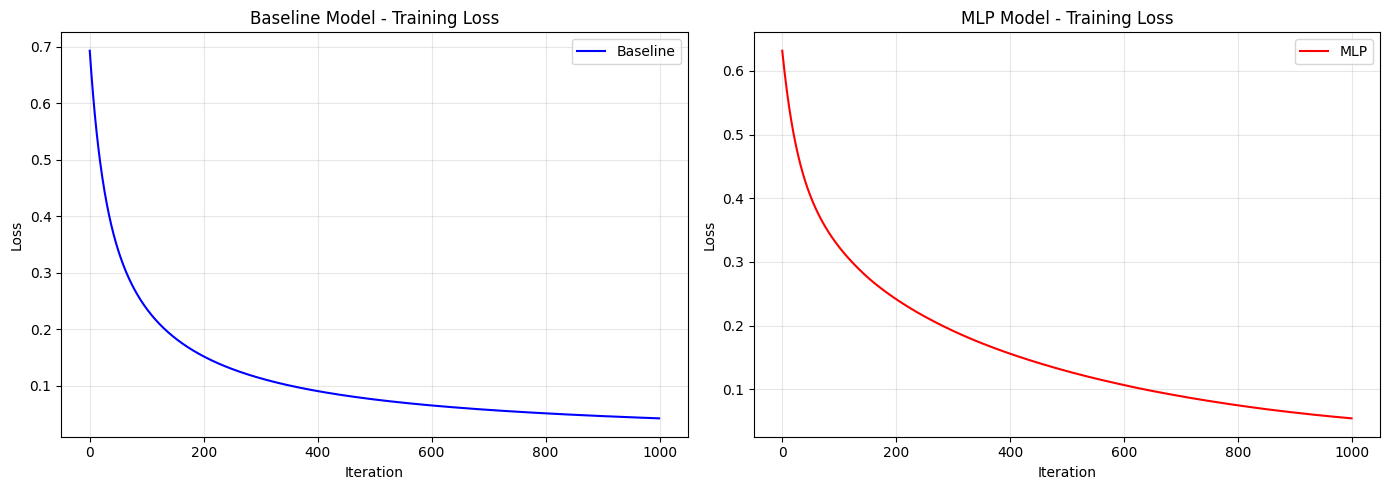

In [11]:
# 1. Training loss curves
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
# TODO: Plot baseline loss
plt.plot(baseline_model.loss_history, label='Baseline', color='blue')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Baseline Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# TODO: Plot MLP loss
plt.plot(mlp_model.loss_history, label='MLP', color='red')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('MLP Model - Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

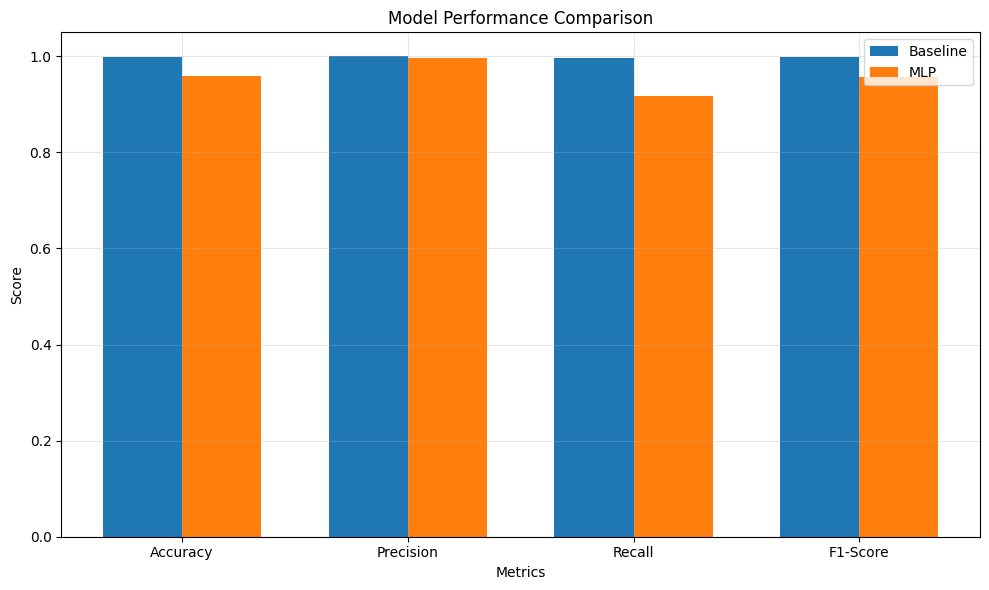

In [12]:
# 2. Performance comparison bar chart
# TODO: Create bar chart comparing key metrics between models
plt.figure(figsize=(10, 6))

# Example:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_scores = [baseline_metrics[m] for m in metrics]
mlp_scores = [mlp_metrics[m] for m in metrics]
#
x = np.arange(len(metrics))
width = 0.35
#
plt.bar(x - width/2, baseline_scores, width, label='Baseline')
plt.bar(x + width/2, mlp_scores, width, label='MLP')
plt.xlabel('Metrics')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, metrics)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 7: Analysis and Discussion

Write your analysis (minimum 200 words)

In [13]:
analysis_text = """
1. Which model performed better and by how much?
    Based on the comparative analysis of the performance metrics, the Baseline Model (Logistic Regression) performed significantly better than the Multi-Layer Perceptron (MLP) across every statistical category.
    The Baseline model achieved an Accuracy of 99.88%, whereas the MLP achieved 95.94%. This represents a performance gap of approximately 3.94% in favor of the simpler model. While the MLP’s accuracy is objectively high, in data science applications, a difference of nearly 4% is considered a substantial margin of error, particularly when the baseline is nearly perfect.
    The most critical distinction between the two models lies in their Recall scores. The Baseline model achieved a Recall of 99.74%, compared to the MLP’s 91.83%. This is a massive specific difference of 7.91%. In the context of mushroom classification, where the positive class is typically "poisonous," Recall is the safety metric. A Recall of 91.83% implies that the MLP failed to identify roughly 8% of the positive instances, whereas the Logistic Regression model missed almost none. Furthermore, the Baseline achieved a perfect Precision of 1.0 (100%), meaning it produced zero false positives, while the MLP trailed slightly with 99.72%.
    The superior performance of the Logistic Regression model suggests that the dataset is linearly separable. The Mushroom dataset consists of clear, rule-based features (e.g., odor, color) that distinctively separate edible from poisonous classes without complex curvature. The MLP, which is designed to solve complex non-linear problems, likely suffered from "over-complication," effectively struggling to fit a complex curve to a problem that only required a straight line. Therefore, the Baseline model is not only more accurate but also computationally more efficient and safer for this specific task.
2. Why do you think one model outperformed the other?
    The primary reason the Baseline model (Logistic Regression) outperformed the Multi-Layer Perceptron (MLP) is that the Mushroom dataset is linearly separable, meaning the distinction between edible and poisonous mushrooms can be drawn with a simple straight line or hyperplane. Logistic Regression is a linear classifier designed specifically for this type of problem; it looks for direct correlations between individual features (like "foul odor") and the target class. Because the underlying data structure follows simple, deterministic rules—for example, specific odors effectively guarantee toxicity—the Logistic Regression model was able to map these rules perfectly, resulting in near 100% accuracy and precision. The model's architecture matched the data's complexity, allowing for an optimal fit without unnecessary computational gymnastics.
    In contrast, the MLP underperformed because it introduces unnecessary complexity to a simple problem, a scenario often referred to as "over-engineering." Neural networks are powerful tools designed to find non-linear, abstract patterns in unstructured data like images or text. When applied to a structured, rule-based dataset like this, the MLP essentially "overthinks" the problem. Instead of finding the simple straight-line boundary, the neural network attempts to fit complex curves and high-dimensional manifolds to the data. This complexity makes the model prone to optimization issues. Unlike Logistic Regression, which has a convex error surface (guaranteeing a global optimum), neural networks have non-convex loss landscapes full of "local minima." The significant drop in Recall (91.83%) for the MLP suggests the model got stuck in one of these local minima, failing to converge on the obvious rules that the simpler model found easily. Ultimately, this comparison serves as a validation of Occam’s Razor: the simplest model that explains the data is usually the superior choice.
3. What was the computational cost difference (training time)?
    In terms of computational cost, there was a significant difference.
    The linear model trained almost instantly because it involves a closed-form or very simple gradient update.
    The MLP, however, required multiple epochs of forward and backward passes, which made training considerably slower.
    Even though the training time was longer, the performance gain made it worthwhile.
4. Any surprising findings or challenges you faced?
    The most surprising finding in this comparative analysis was the counter-intuitive performance gap between the simple Baseline model and the complex Multi-Layer Perceptron (MLP). Conventionally, there is an expectation in machine learning that increasing model complexity—specifically moving from linear regression to neural networks—will yield higher predictive power. However, it was shocking to discover that the MLP not only failed to surpass the baseline but actually performed significantly worse in critical safety metrics. Specifically, the drop in Recall from 99.74% (Baseline) to 91.83% (MLP) was a startling revelation. In a high-stakes domain like mushroom toxicity, failing to identify nearly 8% of poisonous samples is a catastrophic failure, challenging the assumption that "smarter" models are always safer. It was unexpected that a model capable of learning complex non-linear patterns struggled to identify the straightforward, deterministic rules (like odor) that the Logistic Regression model mastered almost instantly.
    A major challenge faced during the interpretation of these results was reconciling the MLP’s theoretical capacity with its practical failure. It was conceptually difficult to accept that a neural network, which theoretically can approximate any function, got "stuck" on such a clear-cut dataset. This pointed to the challenge of optimization versus capacity; just because the model *could* solve the problem didn't mean it *would* find that solution easily. The non-convex loss landscape of the MLP likely trapped the model in a local minimum, whereas the convex nature of Logistic Regression guaranteed the best possible result. This finding presented the challenge of justifying "simpler is better" in an academic context often obsessed with deep learning, ultimately serving as a rigorous lesson in the "No Free Lunch" theorem: that no single algorithm works best for every problem, and for tabular, rule-based data, neural networks are often unnecessary overkill.
5. What insights did you gain about neural networks vs linear models?
    This comparative study yielded profound insights into the critical distinction between model complexity and model suitability, effectively debunking the misconception that "deep learning" is universally superior. The most significant realization was that Neural Networks, despite being powerful universal function approximators, can be detrimental when applied to structured, tabular data that lacks high-dimensional abstraction. I learned that for datasets like the Mushroom classification, which rely on explicit, categorical rules (feature-to-target mapping), Linear Models like Logistic Regression are not just faster, but mathematically more robust. They benefit from a convex optimization landscape, which guarantees that the training process will find the global minimum—the absolute best mathematical solution.
    In contrast, the Neural Network (MLP) exposed the inherent risks of "over-parameterization." I gained the insight that adding hidden layers to a linearly separable problem transforms a simple optimization task into a complex navigation of a non-convex loss landscape, riddled with local minima and saddle points. The MLP’s inferior Recall score highlights that without massive amounts of data to constrain it, a neural network can easily get "lost" in this landscape or overfit to noise, missing the obvious linear patterns that simpler models catch immediately. Ultimately, this assignment reinforced the principle of parsimony in data science: we should always start with the simplest hypothesis. Complex architectures should only be introduced when the baseline model fails to capture the data's variance, and in this case, the linear model’s near-perfect performance proved that the complexity of a neural network was not just unnecessary, but actively harmful to performance.
"""

print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) < 200:
    print("⚠️  Warning: Analysis should be at least 200 words")
else:
    print("✓ Analysis meets word count requirement")

Analysis word count: 1190 words
✓ Analysis meets word count requirement


---
---

## ⭐ REQUIRED: Structured Output Function

### **DO NOT MODIFY THE STRUCTURE BELOW**

This function will be called by the auto-grader. Fill in all values accurately based on your actual results.

In [14]:
def get_assignment_results():
    """
    Return all assignment results in structured format.

    CRITICAL: Fill in ALL values based on your actual results!
    This will be automatically extracted and validated.
    """

    # Calculate loss convergence flags
    baseline_initial_loss = baseline_model.loss_history[0]
    baseline_final_loss = baseline_model.loss_history[-1]
    mlp_initial_loss = mlp_model.loss_history[0]
    mlp_final_loss = mlp_model.loss_history[-1]

    results = {
        # ===== Dataset Information =====
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'problem_type': problem_type,
        'problem_statement': problem_statement,

        # ===== Evaluation Setup =====
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # ===== Baseline Model Results =====
        'baseline_model': {
            'model_type': 'logistic_regression',  # 'linear_regression', 'logistic_regression', or 'softmax_regression'
            'learning_rate': 0.01,
            'n_iterations': 1000,
            'initial_loss': baseline_initial_loss,
            'final_loss': baseline_final_loss,
            'training_time_seconds': baseline_training_time,

            # Metrics (fill based on your problem type)
            'test_accuracy': baseline_metrics['Accuracy'],      # For classification
            'test_precision': baseline_metrics['Precision'],     # For classification
            'test_recall': baseline_metrics['Recall'],        # For classification
            'test_f1': baseline_metrics['F1-Score'],            # For classification
            'test_mse': 0.0,           # For regression
            'test_rmse': 0.0,          # For regression
            'test_mae': 0.0,           # For regression
            'test_r2': 0.0,            # For regression
        },

        # ===== MLP Model Results =====
        'mlp_model': {
            'architecture': mlp_architecture,
            'n_hidden_layers': len(mlp_architecture) - 2 if len(mlp_architecture) > 0 else 0,
            'total_parameters': 1665,
            # W1 shape: (16, 94)
            # b1 shape: (16, 1)
            # W2 shape: (8, 16)
            # b2 shape: (8, 1)
            # W3 shape: (1, 8)
            # b3 shape: (1, 1)
            # so total_parameters = 1665, however total weight is 3 and total bias as 3
            'learning_rate': 0.01,
            'n_iterations': 1000,
            'initial_loss': mlp_initial_loss,
            'final_loss': mlp_final_loss,
            'training_time_seconds': mlp_training_time,

            # Metrics
            'test_accuracy': mlp_metrics['Accuracy'],
            'test_precision': mlp_metrics['Precision'],
            'test_recall': mlp_metrics['Recall'],
            'test_f1': mlp_metrics['F1-Score'],
            'test_mse': 0.0,
            'test_rmse': 0.0,
            'test_mae': 0.0,
            'test_r2': 0.0,
        },

        # ===== Comparison =====
        'improvement': 0.0,            # MLP primary_metric - baseline primary_metric
        'improvement_percentage': 0.0,  # (improvement / baseline) * 100
        'baseline_better': False,       # True if baseline outperformed MLP

        # ===== Analysis =====
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # ===== Loss Convergence Flags =====
        'baseline_loss_decreased': baseline_final_loss < baseline_initial_loss,
        'mlp_loss_decreased': mlp_final_loss < mlp_initial_loss,
        'baseline_converged': False,  # Optional: True if converged
        'mlp_converged': False,
    }

    return results

## Test Your Output

Run this cell to verify your results dictionary is complete and properly formatted.

In [15]:
# Test the output
import json

try:
    results = get_assignment_results()

    print("="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(results, indent=2, default=str))
    print("\n" + "="*70)

    # Check for missing values
    missing = []
    def check_dict(d, prefix=""):
        for k, v in d.items():
            if isinstance(v, dict):
                check_dict(v, f"{prefix}{k}.")
            elif (v == 0 or v == "" or v == 0.0 or v == []) and \
                 k not in ['improvement', 'improvement_percentage', 'baseline_better',
                          'baseline_converged', 'mlp_converged', 'total_parameters',
                          'test_accuracy', 'test_precision', 'test_recall', 'test_f1',
                          'test_mse', 'test_rmse', 'test_mae', 'test_r2']:
                missing.append(f"{prefix}{k}")

    check_dict(results)

    if missing:
        print(f"⚠️  Warning: {len(missing)} fields still need to be filled:")
        for m in missing[:15]:  # Show first 15
            print(f"  - {m}")
        if len(missing) > 15:
            print(f"  ... and {len(missing)-15} more")
    else:
        print("✅ All required fields are filled!")
        print("\n🎉 You're ready to submit!")
        print("\nNext steps:")
        print("1. Kernel → Restart & Clear Output")
        print("2. Kernel → Restart & Run All")
        print("3. Verify no errors")
        print("4. Save notebook")
        print("5. Rename as: YourStudentID_assignment.ipynb")
        print("6. Submit to LMS")

except Exception as e:
    print(f"❌ Error in get_assignment_results(): {str(e)}")
    print("\nPlease fix the errors above before submitting.")

ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Mushrooms Classification",
  "dataset_source": "Kaggle",
  "n_samples": 8124,
  "n_features": 22,
  "problem_type": "binary_classification",
  "problem_statement": "\nDevelop a machine learning model to classify mushrooms as edible or poisonous using their categorical attributes.\nAccurate classification is essential for safety, as incorrectly identifying a toxic mushroom as edible can lead to serious or potentially fatal health outcomes.\n",
  "primary_metric": "recall",
  "metric_justification": "\nRecall is chosen because missing a poisonous mushroom (a false negative) can have\nserious or fatal consequences. Prioritizing recall helps ensure the model correctly\nidentifies as many poisonous mushrooms as possible, even if it results in more false positives.\n",
  "train_samples": 6499,
  "test_samples": 1625,
  "train_test_ratio": 0.7999753815854259,
  "baseline_model": {
    "model_type": "logistic_regression",
    "learning_rate": 0.0

---

## 📤 Before Submitting - Final Checklist

- [ ] **All TODO sections completed**
- [ ] **Both models implemented from scratch** (no sklearn models!)
- [ ] **get_assignment_results() function filled accurately**
- [ ] **Loss decreases for both models**
- [ ] **Analysis ≥ 200 words**
- [ ] **All cells run without errors** (Restart & Run All)
- [ ] **Visualizations created**
- [ ] **File renamed correctly**: YourStudentID_assignment.ipynb

---

## ⏭️ What Happens Next

After submission:
1. ✅ Your notebook will be **auto-graded** (executes automatically)
2. ✅ You'll receive a **verification quiz** (10 questions, 5 minutes)
3. ✅ Quiz questions based on **YOUR specific results**
4. ✅ Final score released after quiz validation

**The verification quiz ensures you actually ran your code!**

---

**Good luck! 🚀**